In [18]:
# 1. Imports
from pathlib import Path
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

PROJECT_ROOT = Path.cwd().parent
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH, override=True)

print("Env file exists:", ENV_PATH.exists())
print("DB_USER:", os.getenv("DB_USER"))
print("DB_HOST:", os.getenv("DB_HOST"))
print("DB_PORT:", os.getenv("DB_PORT"))
print("DB_NAME:", os.getenv("DB_NAME"))

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(db_url)

os.makedirs(PROJECT_ROOT / "outputs" / "figures", exist_ok=True)

print("Connected successfully")












# 7. Business insights

Env file exists: True
DB_USER: olist_user
DB_HOST: localhost
DB_PORT: 5432
DB_NAME: olist_analytics
Connected successfully


In [19]:
# 3. Load order/customer data
query = """
SELECT
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND o.order_purchase_timestamp >= '2017-01-01'
AND o.order_purchase_timestamp < '2018-09-01'
"""

df = pd.read_sql(query, engine)

df.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
2,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05
3,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09
4,e97109680b052ee858d93a539597bba7,82566a660a982b15fb86e904c8d32918,2018-06-07 10:06:19


In [20]:
#cohort retention analysis: after costumers make their first purchase, how many come back and purchase again in later months?


# 4. Build cohorts

#create order month
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["order_month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df.head()

#create cohort month
df["cohort_month"] = (
    df.groupby("customer_unique_id")["order_month"]
    .transform("min")
)

df.head()

#create cohort index
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
    + 1
)

df.head()

#build cohort count tables
cohort_data = (
    df.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

cohort_counts.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20
cohort_month,,,,,,,,,,,,,,,,,,,
2017-01-01,718.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0
2017-02-01,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN
2017-03-01,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN
2017-04-01,2257.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN
2017-05-01,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN


718 customers made their first purchase in January 2017.
2 of those same customers purchased again one month later.
2 purchased again two months later.
1 purchased again three months later.

In [21]:
# 5. Calculate retention matrix
#convert to retention percentage
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

retention.head()


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20
cohort_month,,,,,,,,,,,,,,,,,,,
2017-01-01,100.0,0.278552,0.278552,0.139276,0.417827,0.139276,0.417827,0.139276,0.139276,NaN,0.417827,0.139276,0.696379,0.417827,0.139276,0.139276,0.278552,0.417827,0.139276
2017-02-01,100.0,0.184275,0.307125,0.122850,0.429975,0.122850,0.245700,0.184275,0.122850,0.184275,0.122850,0.307125,0.122850,0.184275,0.122850,0.061425,0.061425,0.184275,NaN
2017-03-01,100.0,0.439473,0.359569,0.399521,0.359569,0.159808,0.159808,0.319616,0.319616,0.079904,0.359569,0.119856,0.199760,0.119856,0.159808,0.239712,0.079904,0.119856,NaN
2017-04-01,100.0,0.620292,0.221533,0.177226,0.265840,0.265840,0.354453,0.310146,0.310146,0.177226,0.265840,0.088613,0.044307,0.044307,0.088613,0.088613,0.132920,NaN,NaN
2017-05-01,100.0,0.463634,0.463634,0.289771,0.289771,0.318748,0.405680,0.144886,0.260794,0.260794,0.260794,0.347725,0.231817,0.028977,0.173863,0.202840,NaN,NaN,NaN


Only 0.28% of January 2017 customers came back the next month.
Only 0.14% came back three months later.

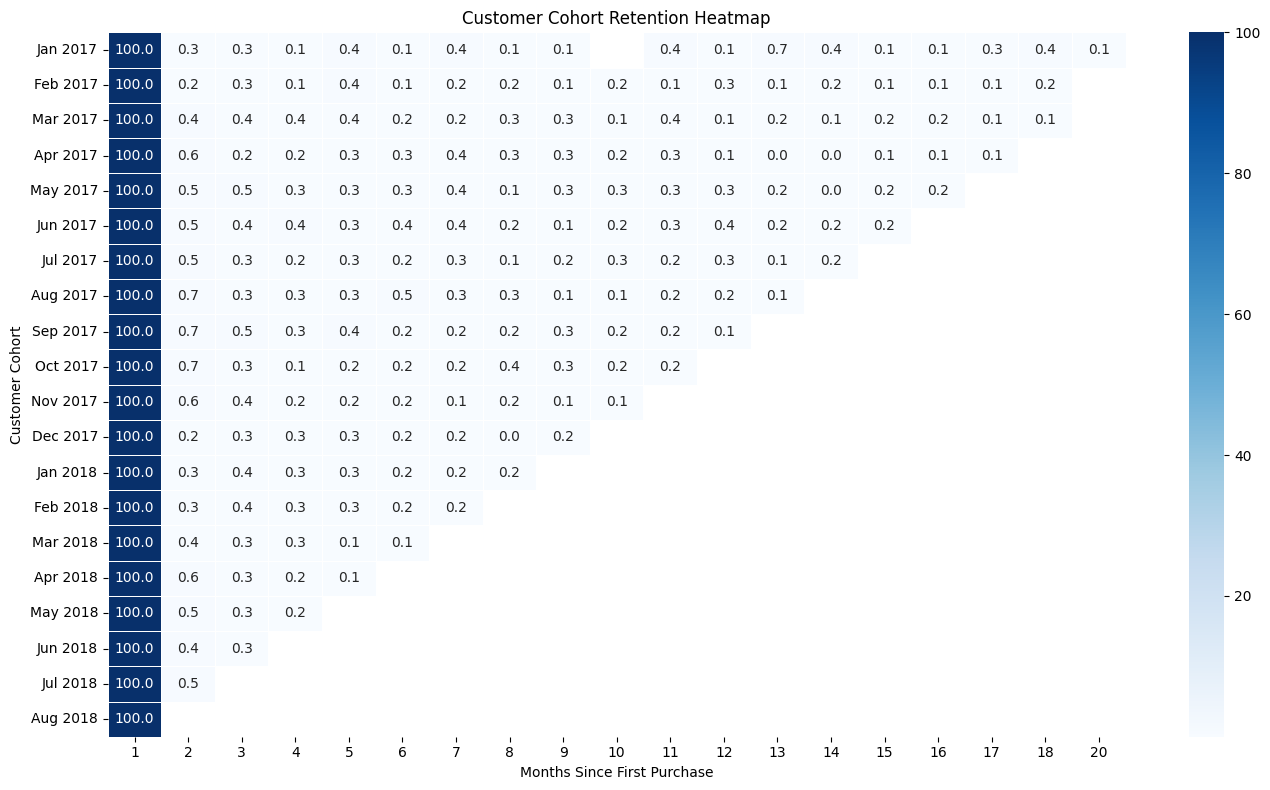

Average Month 1 Retention: 0.48%
Average Month 3 Retention: 0.25%
Average Month 6 Retention: 0.26%


In [22]:

# 6. Create retention heatmap

#convert retention heatmap
retention_plot = retention.copy()

retention_plot.index = retention_plot.index.strftime("%b %Y")

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_plot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "outputs" / "figures" / "06_cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#calculate retention summary
month_1_retention = retention[2].mean()
month_3_retention = retention[4].mean()
month_6_retention = retention[7].mean()

print(f"Average Month 1 Retention: {month_1_retention:.2f}%")
print(f"Average Month 3 Retention: {month_3_retention:.2f}%")
print(f"Average Month 6 Retention: {month_6_retention:.2f}%")

# Business Insight

Cohort retention analysis shows that Olist has very low repeat purchasing behavior. Each cohort begins at 100% in the acquisition month, but retention drops below 1% in nearly all following months. Average Month 1 retention is approximately 0.48%, while Month 3 and Month 6 retention remain around 0.25%.

This suggests that Olist's growth is primarily driven by new customer acquisition rather than repeat customer purchases. For a marketplace-style e-commerce platform, this may be expected because many customers purchase occasionally rather than on a subscription-like basis. However, the low retention rate also highlights an opportunity to improve customer lifetime value through loyalty programs, personalized recommendations, post-purchase email campaigns, and targeted reactivation strategies.

# Business Insight

Customer retention declines sharply after the first purchase. Most cohorts show very low repeat purchasing in the months following acquisition, suggesting that Olist's growth is driven primarily by new customer acquisition rather than repeat customer behavior.

This is typical for marketplace-style e-commerce businesses, where customers may purchase occasionally rather than on a subscription-like basis. Improving personalized recommendations, loyalty programs, and post-purchase marketing could help increase repeat purchase rates and customer lifetime value.